### Question 1

Rows: 10000
Fuel-efficiency summary:
count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64
Skewness: 0.081


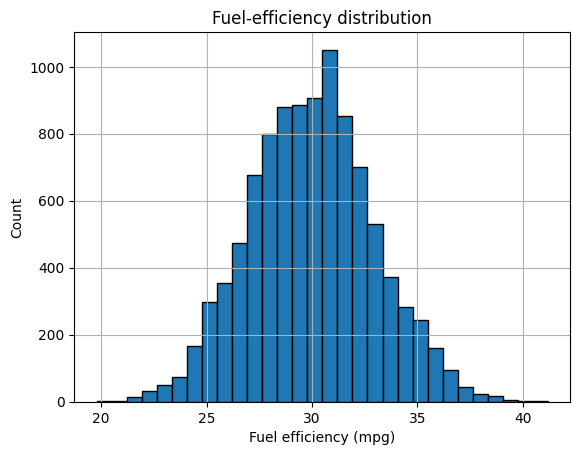

Missing values by column:
horsepower    877
dtype: int64
Q1 answer: horsepower


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

columns = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg",
]
df = pd.read_csv("car_fuel_efficiency_2026.csv")[columns]

print(f"Rows: {len(df)}")
print("Fuel-efficiency summary:")
print(df["fuel_efficiency_mpg"].describe())
print(f"Skewness: {df['fuel_efficiency_mpg'].skew():.3f}")

df["fuel_efficiency_mpg"].hist(bins=30, edgecolor="black")
plt.xlabel("Fuel efficiency (mpg)")
plt.ylabel("Count")
plt.title("Fuel-efficiency distribution")
plt.show()

missing_counts = df.isna().sum()
print("Missing values by column:")
print(missing_counts[missing_counts > 0])
print(f"Q1 answer: {missing_counts[missing_counts > 0].index[0]}")

### Question 2

In [10]:
horsepower_median = df["horsepower"].median()
print(f"Horsepower median: {horsepower_median:g}")

Horsepower median: 254


### Question 3

In [17]:
target = "fuel_efficiency_mpg"
feature_columns = [column for column in columns if column != target]


def split_dataset(data, seed):
    n = len(data)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    data_train = data.iloc[idx[:n_train]]
    data_val = data.iloc[idx[n_train:n_train + n_val]]
    data_test = data.iloc[idx[n_train + n_val:]]
    return data_train, data_val, data_test


def train_linear_regression(X, y, r=0.0):
    X_with_intercept = np.column_stack((np.ones(len(X)), X))
    gram = X_with_intercept.T @ X_with_intercept
    penalty = np.eye(gram.shape[0]) * r
    return np.linalg.solve(gram + penalty, X_with_intercept.T @ y)


def predict_linear_regression(X, weights):
    X_with_intercept = np.column_stack((np.ones(len(X)), X))
    return X_with_intercept @ weights


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def make_features(data, horsepower_fill):
    return data[feature_columns].fillna({"horsepower": horsepower_fill}).to_numpy(dtype=float)


df_train, df_val, df_test = split_dataset(df, seed=42)
mean_horsepower = df_train["horsepower"].mean()
y_train = df_train[target].to_numpy(dtype=float)
y_val = df_val[target].to_numpy(dtype=float)

q3_scores = {}
for option, fill_value in [("With 0", 0), ("With mean", mean_horsepower)]:
    weights = train_linear_regression(make_features(df_train, fill_value), y_train)
    predictions = predict_linear_regression(make_features(df_val, fill_value), weights)
    q3_scores[option] = round(rmse(y_val, predictions), 3)

print(f"Training-only horsepower mean: {mean_horsepower:.3f}")
print(f"Validation RMSE: {q3_scores}")
if q3_scores["With 0"] == q3_scores["With mean"]:
    print("Q3 answer: Both are equally good")
else:
    print(f"Q3 answer: {min(q3_scores, key=q3_scores.get)}")

Training-only horsepower mean: 254.463
Validation RMSE: {'With 0': np.float64(2.205), 'With mean': np.float64(2.202)}
Q3 answer: With mean


### Question 4

In [16]:
regularization_values = [0, 0.01, 0.1, 1, 5, 10, 100]
q4_scores = {}
q4_raw_scores = {}

for regularization in regularization_values:
    weights = train_linear_regression(
        make_features(df_train, 0),
        y_train,
        r=regularization,
    )
    predictions = predict_linear_regression(make_features(df_val, 0), weights)
    raw_score = rmse(y_val, predictions)
    q4_raw_scores[regularization] = raw_score
    q4_scores[regularization] = round(raw_score, 4)

best_regularization = min(
    regularization_values,
    key=lambda value: (q4_scores[value], value),
)
print(f"Validation RMSE (full precision): {q4_raw_scores}")
print(f"Validation RMSE (rounded to 4 decimals): {q4_scores}")
print(f"Q4 answer: r={best_regularization}")

Validation RMSE (full precision): {0: np.float64(2.205293194751562), 0.01: np.float64(2.2052931947971586), 0.1: np.float64(2.205293195207447), 1: np.float64(2.2052931993112095), 5: np.float64(2.205293217556685), 10: np.float64(2.205293240379057), 100: np.float64(2.2052936541437886)}
Validation RMSE (rounded to 4 decimals): {0: np.float64(2.2053), 0.01: np.float64(2.2053), 0.1: np.float64(2.2053), 1: np.float64(2.2053), 5: np.float64(2.2053), 10: np.float64(2.2053), 100: np.float64(2.2053)}
Q4 answer: r=0


### Question 5

In [18]:
seeds = list(range(10))
q5_scores = []

for seed in seeds:
    seed_train, seed_val, _ = split_dataset(df, seed=seed)
    seed_y_train = seed_train[target].to_numpy(dtype=float)
    seed_y_val = seed_val[target].to_numpy(dtype=float)

    weights = train_linear_regression(make_features(seed_train, 0), seed_y_train)
    predictions = predict_linear_regression(make_features(seed_val, 0), weights)
    q5_scores.append(rmse(seed_y_val, predictions))

q5_std = np.std(q5_scores)
print("Validation RMSE by seed:")
print({seed: round(score, 6) for seed, score in zip(seeds, q5_scores)})
print(f"RMSE standard deviation: {q5_std:.6f}")
print(f"Q5 answer (rounded to 3 decimals): {round(q5_std, 3)}")

Validation RMSE by seed:
{0: np.float64(2.239204), 1: np.float64(2.202113), 2: np.float64(2.16342), 3: np.float64(2.204359), 4: np.float64(2.20188), 5: np.float64(2.245785), 6: np.float64(2.269721), 7: np.float64(2.190795), 8: np.float64(2.216611), 9: np.float64(2.207037)}
RMSE standard deviation: 0.028781
Q5 answer (rounded to 3 decimals): 0.029


### Question 6

In [19]:
q6_train, q6_val, q6_test = split_dataset(df, seed=9)
q6_train_and_val = pd.concat([q6_train, q6_val])

q6_y_train = q6_train_and_val[target].to_numpy(dtype=float)
q6_y_test = q6_test[target].to_numpy(dtype=float)
q6_weights = train_linear_regression(
    make_features(q6_train_and_val, 0),
    q6_y_train,
    r=0.001,
)
q6_predictions = predict_linear_regression(make_features(q6_test, 0), q6_weights)
q6_test_rmse = rmse(q6_y_test, q6_predictions)

print(f"Test RMSE: {q6_test_rmse:.6f}")
print(f"Q6 answer (rounded to 3 decimals): {round(q6_test_rmse, 3)}")

Test RMSE: 2.235828
Q6 answer (rounded to 3 decimals): 2.236
